In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import zipfile
import requests
from io import BytesIO

url = "https://files.grouplens.org/datasets/movielens/ml-1m.zip"

response = requests.get(url)
zip_file = zipfile.ZipFile(BytesIO(response.content))

zip_file.extractall(".")

print("Dataset downloaded and extracted successfully!")

Dataset downloaded and extracted successfully!


In [3]:
movies = pd.read_csv(
    "ml-1m/movies.dat",
    sep="::",
    engine="python",
    encoding="latin-1",
    names=["movieId", "title", "genres"]
)

movies.head()


,movieId,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
ratings = pd.read_csv(
    "ml-1m/ratings.dat",
    sep="::",
    engine="python",
    encoding="latin-1",
    names=["userId", "movieId", "rating", "timestamp"]
)

ratings.head()

,userId,movieId,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [5]:
print("Movies dataset shape:", movies.shape)
print("Ratings dataset shape:", ratings.shape)

Movies dataset shape: (3883, 3)
Ratings dataset shape: (1000209, 4)


In [6]:
ratings["rating"].value_counts().sort_index()

,count
rating,
1,56174
2,107557
3,261197
4,348971
5,226310


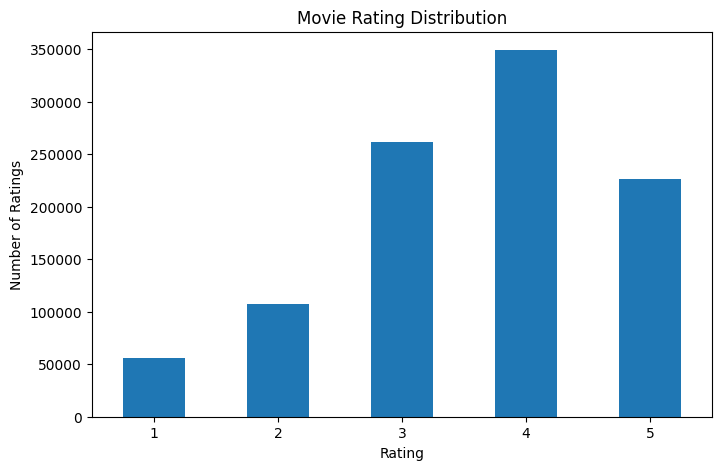

In [7]:
ratings["rating"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Movie Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=0)
plt.show()

In [8]:
movie_rating_counts = ratings["movieId"].value_counts()

top_rated_movies = movie_rating_counts.head(10)

top_rated_movies

,count
movieId,
2858,3428
260,2991
1196,2990
1210,2883
480,2672
2028,2653
589,2649
2571,2590
1270,2583


In [9]:
top_movies = (
    movies[movies["movieId"].isin(top_rated_movies.index)]
    .merge(
        top_rated_movies.rename("rating_count"),
        left_on="movieId",
        right_index=True
    )
    .sort_values("rating_count", ascending=False)
)

top_movies[["movieId", "title", "rating_count"]]

,movieId,title,rating_count
2789,2858,American Beauty (1999),3428
257,260,Star Wars: Episode IV - A New Hope (1977),2991
1178,1196,Star Wars: Episode V - The Empire Strikes Back...,2990
1192,1210,Star Wars: Episode VI - Return of the Jedi (1983),2883
476,480,Jurassic Park (1993),2672
1959,2028,Saving Private Ryan (1998),2653
585,589,Terminator 2: Judgment Day (1991),2649
2502,2571,"Matrix, The (1999)",2590
1250,1270,Back to the Future (1985),2583
589,593,"Silence of the Lambs, The (1991)",2578


In [10]:
movie_stats = (
    ratings.groupby("movieId")["rating"]
    .agg(["mean", "count"])
    .reset_index()
)

movie_stats.columns = ["movieId", "avg_rating", "rating_count"]

movie_stats.head()

,movieId,avg_rating,rating_count
0,1,4.146846,2077
1,2,3.201141,701
2,3,3.016736,478
3,4,2.729412,170
4,5,3.006757,296


In [11]:
movie_data = movies.merge(
    movie_stats,
    on="movieId"
)

movie_data.head()

,movieId,title,genres,avg_rating,rating_count
0,1,Toy Story (1995),Animation|Children's|Comedy,4.146846,2077
1,2,Jumanji (1995),Adventure|Children's|Fantasy,3.201141,701
2,3,Grumpier Old Men (1995),Comedy|Romance,3.016736,478
3,4,Waiting to Exhale (1995),Comedy|Drama,2.729412,170
4,5,Father of the Bride Part II (1995),Comedy,3.006757,296


In [12]:
top_rated = (
    movie_data[movie_data["rating_count"] >= 100]
    .sort_values("avg_rating", ascending=False)
    .head(10)
)

top_rated[["title", "avg_rating", "rating_count"]]

,title,avg_rating,rating_count
1839,Seven Samurai (The Magnificent Seven) (Shichin...,4.560510,628
309,"Shawshank Redemption, The (1994)",4.554558,2227
802,"Godfather, The (1972)",4.524966,2223
708,"Close Shave, A (1995)",4.520548,657
49,"Usual Suspects, The (1995)",4.517106,1783
513,Schindler's List (1993),4.510417,2304
1066,"Wrong Trousers, The (1993)",4.507937,882
861,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),4.491489,470
1108,Raiders of the Lost Ark (1981),4.477725,2514
843,Rear Window (1954),4.476190,1050


In [13]:
all_genres = set()

for genres in movies["genres"]:
    all_genres.update(genres.split("|"))

all_genres = sorted(all_genres)

print("Number of genres:", len(all_genres))
print("\nGenres:")
print(all_genres)

Number of genres: 18

Genres:
['Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


In [14]:
genre_counts = {}

for genres in movies["genres"]:
    for genre in genres.split("|"):
        genre_counts[genre] = genre_counts.get(genre, 0) + 1

genre_counts = pd.Series(genre_counts).sort_values(ascending=False)

genre_counts

,0
Drama,1603
Comedy,1200
Action,503
Thriller,492
Romance,471
Horror,343
Adventure,283
Sci-Fi,276
Children's,251
Crime,211


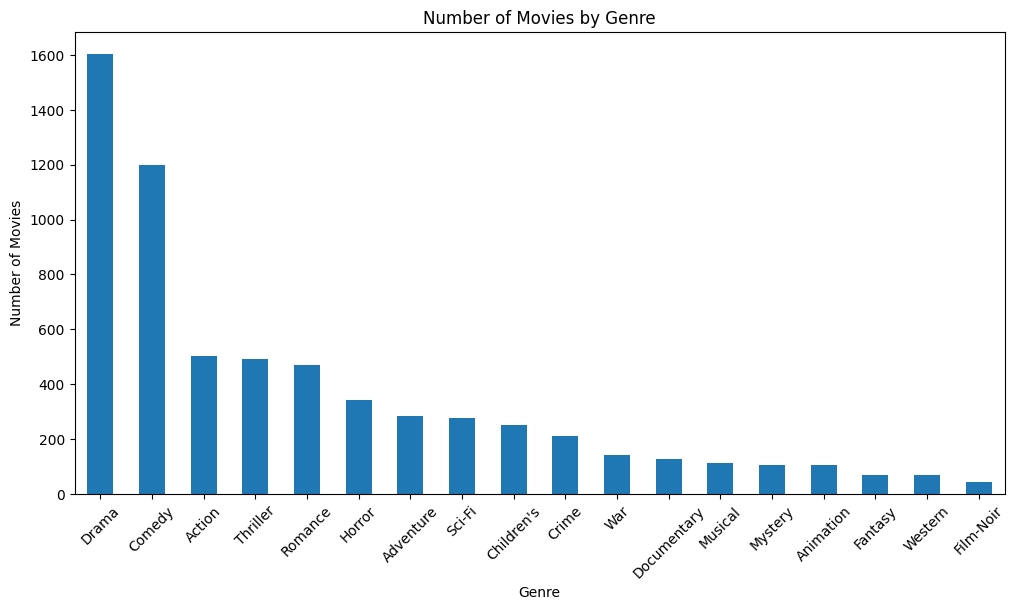

In [15]:
genre_counts.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Number of Movies by Genre")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.show()

In [16]:
movies["genres_text"] = movies["genres"].str.replace("|", " ", regex=False)

movies[["title", "genres", "genres_text"]].head()

,title,genres,genres_text
0,Toy Story (1995),Animation|Children's|Comedy,Animation Children's Comedy
1,Jumanji (1995),Adventure|Children's|Fantasy,Adventure Children's Fantasy
2,Grumpier Old Men (1995),Comedy|Romance,Comedy Romance
3,Waiting to Exhale (1995),Comedy|Drama,Comedy Drama
4,Father of the Bride Part II (1995),Comedy,Comedy


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

tfidf_matrix = tfidf.fit_transform(movies["genres_text"])

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (3883, 20)


In [18]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix)

print("Similarity matrix shape:", cosine_sim.shape)

Similarity matrix shape: (3883, 3883)


In [19]:
indices = pd.Series(movies.index, index=movies["title"]).drop_duplicates()

def recommend_movies(title, num_recommendations=10):
    idx = indices[title]

    similarity_scores = list(enumerate(cosine_sim[idx]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:num_recommendations + 1]

    movie_indices = [i[0] for i in similarity_scores]

    return movies.iloc[movie_indices][["title", "genres"]]

In [20]:
recommend_movies("Toy Story (1995)")

,title,genres
1050,Aladdin and the King of Thieves (1996),Animation|Children's|Comedy
2072,"American Tail, An (1986)",Animation|Children's|Comedy
2073,"American Tail: Fievel Goes West, An (1991)",Animation|Children's|Comedy
2285,"Rugrats Movie, The (1998)",Animation|Children's|Comedy
2286,"Bug's Life, A (1998)",Animation|Children's|Comedy
3045,Toy Story 2 (1999),Animation|Children's|Comedy
3542,Saludos Amigos (1943),Animation|Children's|Comedy
3682,Chicken Run (2000),Animation|Children's|Comedy
3685,"Adventures of Rocky and Bullwinkle, The (2000)",Animation|Children's|Comedy
12,Balto (1995),Animation|Children's


In [21]:
recommend_movies("The Matrix (1999)")

KeyError: 'The Matrix (1999)'

In [24]:
def search_movies(keyword):
    return movies[
        movies["title"].str.contains(keyword, case=False, na=False)
    ][["movieId", "title", "genres"]]

In [25]:
search_movies("matrix")

,movieId,title,genres
2502,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller


In [27]:
user_movie_matrix = ratings.pivot_table(
    index="userId",
    columns="movieId",
    values="rating"
)

user_movie_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,3943,3944,3945,3946,3947,3948,3949,3950,3951,3952
userId,,,,,,,,,,,,,,,,,,,,,
1,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
print("Number of users:", user_movie_matrix.shape[0])
print("Number of movies:", user_movie_matrix.shape[1])

Number of users: 6040
Number of movies: 3706


In [29]:
user_movie_matrix_filled = user_movie_matrix.fillna(0)

user_movie_matrix_filled.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,3943,3944,3945,3946,3947,3948,3949,3950,3951,3952
userId,,,,,,,,,,,,,,,,,,,,,
1,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [30]:
from sklearn.metrics.pairwise import cosine_similarity

movie_similarity = cosine_similarity(user_movie_matrix_filled.T)

print("Movie similarity matrix shape:", movie_similarity.shape)

Movie similarity matrix shape: (3706, 3706)


In [31]:
movie_indices = pd.Series(
    range(len(user_movie_matrix_filled.columns)),
    index=user_movie_matrix_filled.columns
)

def collaborative_recommend(movie_id, num_recommendations=10):
    idx = movie_indices[movie_id]

    similarity_scores = list(enumerate(movie_similarity[idx]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:num_recommendations + 1]

    similar_movie_ids = [
        user_movie_matrix_filled.columns[i[0]]
        for i in similarity_scores
    ]

    return movies[movies["movieId"].isin(similar_movie_ids)][
        ["movieId", "title", "genres"]
    ]

In [32]:
collaborative_recommend(2571)

,movieId,title,genres
257,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Fantasy|Sci-Fi
453,457,"Fugitive, The (1993)",Action|Thriller
476,480,Jurassic Park (1993),Action|Adventure|Sci-Fi
585,589,Terminator 2: Judgment Day (1991),Action|Sci-Fi|Thriller
1178,1196,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Drama|Sci-Fi|War
1192,1210,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Romance|Sci-Fi|War
1220,1240,"Terminator, The (1984)",Action|Sci-Fi|Thriller
1491,1527,"Fifth Element, The (1997)",Action|Sci-Fi
1539,1580,Men in Black (1997),Action|Adventure|Comedy|Sci-Fi
2847,2916,Total Recall (1990),Action|Adventure|Sci-Fi|Thriller


In [33]:
print("CONTENT-BASED RECOMMENDATIONS")
print("--------------------------------")
print(recommend_movies("Matrix, The (1999)"))

print("\nCOLLABORATIVE RECOMMENDATIONS")
print("--------------------------------")
print(collaborative_recommend(2571))

CONTENT-BASED RECOMMENDATIONS
--------------------------------
                                  title                  genres
283            Nemesis 2: Nebula (1995)  Action|Sci-Fi|Thriller
585   Terminator 2: Judgment Day (1991)  Action|Sci-Fi|Thriller
683                         Solo (1996)  Action|Sci-Fi|Thriller
738                 Arrival, The (1996)  Action|Sci-Fi|Thriller
1024          Lawnmower Man, The (1992)  Action|Sci-Fi|Thriller
1220             Terminator, The (1984)  Action|Sci-Fi|Thriller
1533                    Face/Off (1997)  Action|Sci-Fi|Thriller
1763               Lost in Space (1998)  Action|Sci-Fi|Thriller
2502                 Matrix, The (1999)  Action|Sci-Fi|Thriller
2531                    eXistenZ (1999)  Action|Sci-Fi|Thriller

COLLABORATIVE RECOMMENDATIONS
--------------------------------
      movieId                                              title  \
257       260          Star Wars: Episode IV - A New Hope (1977)   
453       457                    

In [36]:
def hybrid_recommend(title, movie_id, num_recommendations=10):
    # Content-based recommendations
    content_recs = recommend_movies(
        title,
        num_recommendations=20
    )

    # Add movieId to content recommendations
    content_recs = content_recs.merge(
        movies[["movieId", "title"]],
        on="title",
        how="left"
    )

    # Collaborative recommendations
    collaborative_recs = collaborative_recommend(
        movie_id,
        num_recommendations=20
    )

    # Combine both methods
    combined = pd.concat([
        content_recs[["movieId", "title", "genres"]],
        collaborative_recs[["movieId", "title", "genres"]]
    ])

    # Remove duplicates and original movie
    combined = combined.drop_duplicates(subset="movieId")
    combined = combined[combined["movieId"] != movie_id]

    return combined.head(num_recommendations)

In [37]:
hybrid_recommend(
    "Matrix, The (1999)",
    2571
)

,movieId,title,genres
0,286,Nemesis 2: Nebula (1995),Action|Sci-Fi|Thriller
1,589,Terminator 2: Judgment Day (1991),Action|Sci-Fi|Thriller
2,692,Solo (1996),Action|Sci-Fi|Thriller
3,748,"Arrival, The (1996)",Action|Sci-Fi|Thriller
4,1037,"Lawnmower Man, The (1992)",Action|Sci-Fi|Thriller
5,1240,"Terminator, The (1984)",Action|Sci-Fi|Thriller
6,1573,Face/Off (1997),Action|Sci-Fi|Thriller
7,1831,Lost in Space (1998),Action|Sci-Fi|Thriller
9,2600,eXistenZ (1999),Action|Sci-Fi|Thriller
10,2722,Deep Blue Sea (1999),Action|Sci-Fi|Thriller


In [38]:
hybrid_result = hybrid_recommend(
    "Matrix, The (1999)",
    2571
)

hybrid_result[["movieId", "title", "genres"]]

,movieId,title,genres
0,286,Nemesis 2: Nebula (1995),Action|Sci-Fi|Thriller
1,589,Terminator 2: Judgment Day (1991),Action|Sci-Fi|Thriller
2,692,Solo (1996),Action|Sci-Fi|Thriller
3,748,"Arrival, The (1996)",Action|Sci-Fi|Thriller
4,1037,"Lawnmower Man, The (1992)",Action|Sci-Fi|Thriller
5,1240,"Terminator, The (1984)",Action|Sci-Fi|Thriller
6,1573,Face/Off (1997),Action|Sci-Fi|Thriller
7,1831,Lost in Space (1998),Action|Sci-Fi|Thriller
9,2600,eXistenZ (1999),Action|Sci-Fi|Thriller
10,2722,Deep Blue Sea (1999),Action|Sci-Fi|Thriller


In [41]:
def weighted_hybrid_recommend(title, movie_id, num_recommendations=10):
    # Content-based recommendations
    content_recs = recommend_movies(title, num_recommendations=20)

    # Add movieId using the movie title
    content_recs = content_recs.merge(
        movies[["movieId", "title"]],
        on="title",
        how="left"
    )

    content_recs["content_score"] = np.linspace(
        1, 0.1, len(content_recs)
    )

    # Collaborative recommendations
    collaborative_recs = collaborative_recommend(
        movie_id,
        num_recommendations=20
    )

    collaborative_recs["collab_score"] = np.linspace(
        1, 0.1, len(collaborative_recs)
    )

    # Keep only the required columns
    content_scores = content_recs[
        ["movieId", "content_score"]
    ]

    collaborative_scores = collaborative_recs[
        ["movieId", "collab_score"]
    ]

    # Combine scores using movieId
    combined = pd.merge(
        content_scores,
        collaborative_scores,
        on="movieId",
        how="outer"
    )

    # Fill missing scores
    combined["content_score"] = combined["content_score"].fillna(0)
    combined["collab_score"] = combined["collab_score"].fillna(0)

    # Calculate hybrid score
    combined["hybrid_score"] = (
        0.5 * combined["content_score"] +
        0.5 * combined["collab_score"]
    )

    # Remove the original movie
    combined = combined[combined["movieId"] != movie_id]

    # Add movie information
    combined = combined.merge(
        movies[["movieId", "title", "genres"]],
        on="movieId",
        how="left"
    )

    # Sort by hybrid score
    combined = combined.sort_values(
        "hybrid_score",
        ascending=False
    )

    return combined[
        ["movieId", "title", "genres",
         "content_score", "collab_score", "hybrid_score"]
    ].head(num_recommendations)

In [42]:
weighted_hybrid_recommend(
    "Matrix, The (1999)",
    2571
)

,movieId,title,genres,content_score,collab_score,hybrid_score
11,589,Terminator 2: Judgment Day (1991),Action|Sci-Fi|Thriller,0.952632,0.763158,0.857895
21,1240,"Terminator, The (1984)",Action|Sci-Fi|Thriller,0.763158,0.431579,0.597368
23,1573,Face/Off (1997),Action|Sci-Fi|Thriller,0.715789,0.336842,0.526316
0,32,Twelve Monkeys (1995),Drama|Sci-Fi,0.000000,1.000000,0.500000
6,286,Nemesis 2: Nebula (1995),Action|Sci-Fi|Thriller,1.000000,0.000000,0.500000
3,110,Braveheart (1995),Action|Drama|War,0.000000,0.952632,0.476316
5,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Fantasy|Sci-Fi,0.000000,0.905263,0.452632
12,692,Solo (1996),Action|Sci-Fi|Thriller,0.905263,0.000000,0.452632
13,748,"Arrival, The (1996)",Action|Sci-Fi|Thriller,0.857895,0.000000,0.428947
8,457,"Fugitive, The (1993)",Action|Thriller,0.000000,0.857895,0.428947


In [43]:
print("MOVIE RECOMMENDATION SYSTEM")
print("============================")
print("Dataset: MovieLens 1M")
print("Movies:", len(movies))
print("Ratings:", len(ratings))
print()
print("Models implemented:")
print("1. Content-Based Filtering")
print("   - TF-IDF")
print("   - Cosine Similarity")
print()
print("2. Collaborative Filtering")
print("   - User-Movie Rating Matrix")
print("   - Movie-Movie Cosine Similarity")
print()
print("3. Hybrid Recommendation")
print("   - Content + Collaborative Filtering")

MOVIE RECOMMENDATION SYSTEM
Dataset: MovieLens 1M
Movies: 3883
Ratings: 1000209

Models implemented:
1. Content-Based Filtering
   - TF-IDF
   - Cosine Similarity

2. Collaborative Filtering
   - User-Movie Rating Matrix
   - Movie-Movie Cosine Similarity

3. Hybrid Recommendation
   - Content + Collaborative Filtering


In [44]:
user_rating_counts = ratings.groupby("userId")["rating"].count()

print(user_rating_counts.describe())

count    6040.000000
mean      165.597517
std       192.747029
min        20.000000
25%        44.000000
50%        96.000000
75%       208.000000
max      2314.000000
Name: rating, dtype: float64


In [45]:
from sklearn.model_selection import train_test_split

train_ratings = []
test_ratings = []

for user_id, user_data in ratings.groupby("userId"):
    train, test = train_test_split(
        user_data,
        test_size=0.2,
        random_state=42
    )

    train_ratings.append(train)
    test_ratings.append(test)

train_ratings = pd.concat(train_ratings)
test_ratings = pd.concat(test_ratings)

print("Training ratings:", len(train_ratings))
print("Testing ratings:", len(test_ratings))

Training ratings: 797758
Testing ratings: 202451


In [46]:
from sklearn.metrics import mean_squared_error

movie_avg_ratings = (
    train_ratings.groupby("movieId")["rating"]
    .mean()
)

test_with_predictions = test_ratings.copy()

test_with_predictions["predicted_rating"] = (
    test_with_predictions["movieId"]
    .map(movie_avg_ratings)
)

# Remove movies that don't appear in training data
test_with_predictions = test_with_predictions.dropna(
    subset=["predicted_rating"]
)

rmse = np.sqrt(
    mean_squared_error(
        test_with_predictions["rating"],
        test_with_predictions["predicted_rating"]
    )
)

print("Baseline RMSE:", round(rmse, 4))

Baseline RMSE: 0.9799


In [47]:
from sklearn.decomposition import TruncatedSVD

# Create training user-movie matrix
train_matrix = train_ratings.pivot_table(
    index="userId",
    columns="movieId",
    values="rating"
)

# Calculate each user's average rating
user_means = train_matrix.mean(axis=1)

# Center ratings around each user's average
centered_matrix = train_matrix.sub(user_means, axis=0)

# Missing ratings become 0 for SVD
centered_matrix = centered_matrix.fillna(0)

# Train SVD
svd = TruncatedSVD(
    n_components=50,
    random_state=42
)

user_factors = svd.fit_transform(centered_matrix)
movie_factors = svd.components_

print("SVD model trained successfully!")
print("Number of latent factors:", svd.n_components)

SVD model trained successfully!
Number of latent factors: 50


In [48]:
# Reconstruct the predicted rating matrix
predicted_matrix = (
    np.dot(user_factors, movie_factors) +
    user_means.values.reshape(-1, 1)
)

# Convert predictions into a DataFrame
predicted_ratings = pd.DataFrame(
    predicted_matrix,
    index=train_matrix.index,
    columns=train_matrix.columns
)

# Get predictions for the test ratings
test_with_svd = test_ratings.copy()

test_with_svd["predicted_rating"] = [
    predicted_ratings.loc[user_id, movie_id]
    if user_id in predicted_ratings.index
    and movie_id in predicted_ratings.columns
    else np.nan
    for user_id, movie_id in zip(
        test_with_svd["userId"],
        test_with_svd["movieId"]
    )
]

test_with_svd = test_with_svd.dropna(
    subset=["predicted_rating"]
)

svd_rmse = np.sqrt(
    mean_squared_error(
        test_with_svd["rating"],
        test_with_svd["predicted_rating"]
    )
)

print("SVD RMSE:", round(svd_rmse, 4))

SVD RMSE: 0.965


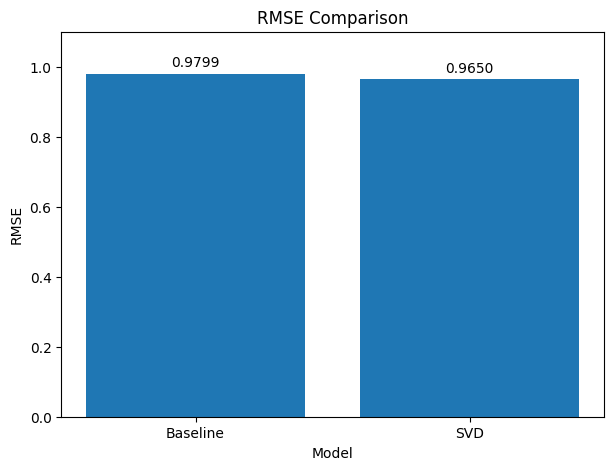

In [49]:
model_names = ["Baseline", "SVD"]
rmse_values = [0.9799, 0.9650]

plt.figure(figsize=(7, 5))
plt.bar(model_names, rmse_values)

plt.title("RMSE Comparison")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.ylim(0, 1.1)

for i, value in enumerate(rmse_values):
    plt.text(i, value + 0.02, f"{value:.4f}", ha="center")

plt.show()

In [50]:
def svd_recommend(user_id, num_recommendations=10):
    if user_id not in predicted_ratings.index:
        print("User not found.")
        return

    # Get predicted ratings for the user
    user_predictions = predicted_ratings.loc[user_id]

    # Get movies the user has already rated
    watched_movies = set(
        ratings[ratings["userId"] == user_id]["movieId"]
    )

    # Remove already-rated movies
    recommendations = user_predictions[
        ~user_predictions.index.isin(watched_movies)
    ]

    # Get top recommendations
    top_movies = recommendations.sort_values(
        ascending=False
    ).head(num_recommendations)

    # Convert movie IDs to movie information
    result = movies[
        movies["movieId"].isin(top_movies.index)
    ][["movieId", "title", "genres"]].copy()

    # Add predicted rating
    result["predicted_rating"] = result["movieId"].map(top_movies)

    return result.sort_values(
        "predicted_rating",
        ascending=False
    )

In [51]:
svd_recommend(1, 10)

,movieId,title,genres,predicted_rating
476,480,Jurassic Park (1993),Action|Adventure|Sci-Fi,4.416063
315,318,"Shawshank Redemption, The (1994)",Drama,4.398459
3684,3753,"Patriot, The (2000)",Action|Drama|War,4.386153
108,110,Braveheart (1995),Action|Drama|War,4.372517
352,356,Forrest Gump (1994),Comedy|Romance|War,4.362492
586,590,Dances with Wolves (1990),Adventure|Drama|Western,4.354901
1943,2012,Back to the Future Part III (1990),Comedy|Sci-Fi|Western,4.341701
1230,1250,"Bridge on the River Kwai, The (1957)",Drama|War,4.334995
360,364,"Lion King, The (1994)",Animation|Children's|Musical,4.329959
1222,1242,Glory (1989),Action|Drama|War,4.321801


In [52]:
svd_recommend(100, 10)

,movieId,title,genres,predicted_rating
900,912,Casablanca (1942),Drama|Romance|War,3.413970
2255,2324,Life Is Beautiful (La Vita è bella) (1997),Comedy|Drama,3.359152
293,296,Pulp Fiction (1994),Crime|Drama,3.322268
1250,1270,Back to the Future (1985),Comedy|Sci-Fi,3.290123
2693,2762,"Sixth Sense, The (1999)",Thriller,3.285291
453,457,"Fugitive, The (1993)",Action|Thriller,3.282539
2722,2791,Airplane! (1980),Comedy,3.265240
911,923,Citizen Kane (1941),Drama,3.248138
1120,1136,Monty Python and the Holy Grail (1974),Comedy,3.245289
908,920,Gone with the Wind (1939),Drama|Romance|War,3.236318


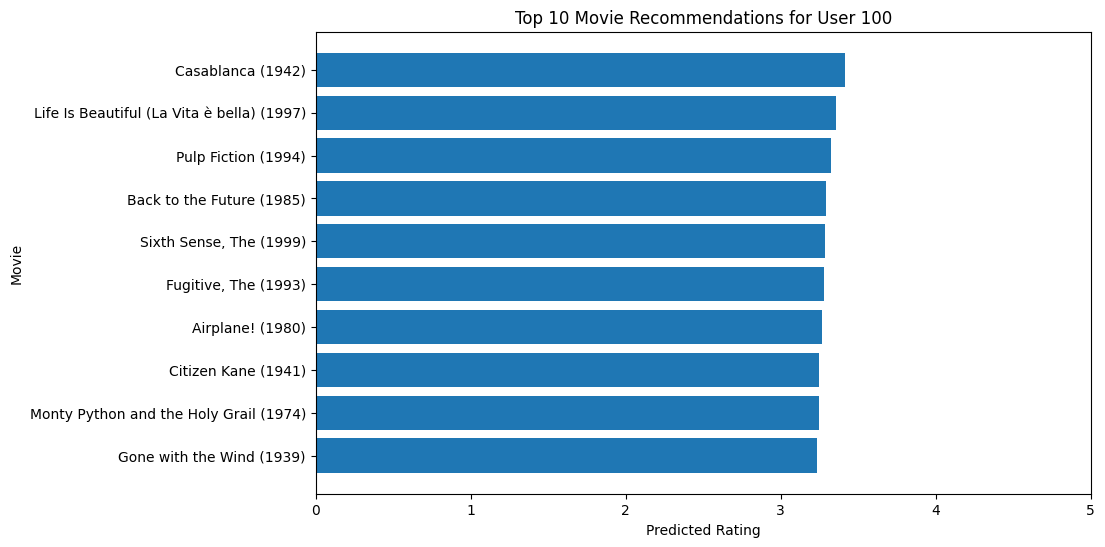

In [53]:
recommendations = svd_recommend(100, 10)

plt.figure(figsize=(10, 6))

plt.barh(
    recommendations["title"][::-1],
    recommendations["predicted_rating"][::-1]
)

plt.xlabel("Predicted Rating")
plt.ylabel("Movie")
plt.title("Top 10 Movie Recommendations for User 100")
plt.xlim(0, 5)

plt.show()

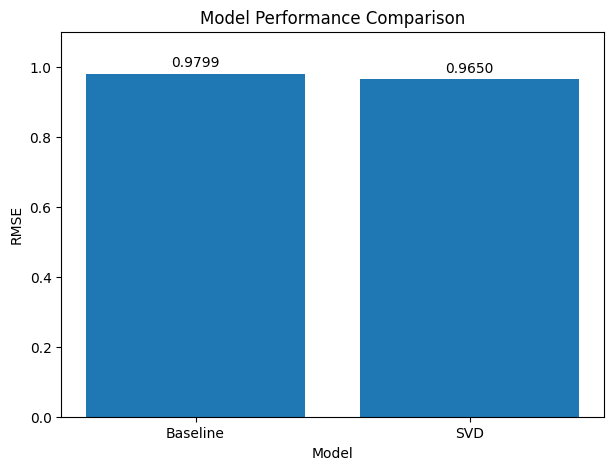

In [54]:
id="model_comparison_46"
models = ["Baseline", "SVD"]
rmse = [0.9799, 0.9650]

plt.figure(figsize=(7, 5))

plt.bar(models, rmse)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.ylim(0, 1.1)

for i, value in enumerate(rmse):
    plt.text(i, value + 0.02, f"{value:.4f}", ha="center")

plt.show()

In [55]:
id="topk_eval_47"
# Movies that users rated highly in the test set

relevant_movies = (
    test_ratings[test_ratings["rating"] >= 4]
    .groupby("userId")["movieId"]
    .apply(set)
)

print("Number of users with relevant test movies:", len(relevant_movies))

Number of users with relevant test movies: 6025


In [56]:
from sklearn.metrics import precision_score, recall_score

precisions = []
recalls = []

for user_id in relevant_movies.index:

    # Get user's predicted ratings
    user_predictions = predicted_ratings.loc[user_id]

    # Movies already rated in the training set
    watched_movies = set(
        train_ratings[
            train_ratings["userId"] == user_id
        ]["movieId"]
    )

    # Remove already-rated movies
    recommendations = user_predictions[
        ~user_predictions.index.isin(watched_movies)
    ]

    # Top 10 recommendations
    top_10 = set(
        recommendations
        .sort_values(ascending=False)
        .head(10)
        .index
    )

    # Movies the user actually liked in the test set
    relevant = relevant_movies[user_id]

    # Calculate Precision@10
    precision = len(top_10 & relevant) / 10

    # Calculate Recall@10
    recall = len(top_10 & relevant) / len(relevant)

    precisions.append(precision)
    recalls.append(recall)

print("Precision@10:", round(np.mean(precisions), 4))
print("Recall@10:", round(np.mean(recalls), 4))

Precision@10: 0.1801
Recall@10: 0.1067


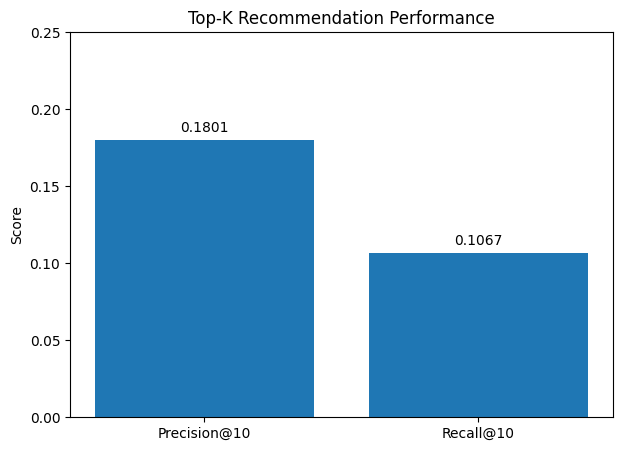

In [57]:
metrics = ["Precision@10", "Recall@10"]
values = [0.1801, 0.1067]

plt.figure(figsize=(7, 5))

plt.bar(metrics, values)

plt.title("Top-K Recommendation Performance")
plt.ylabel("Score")
plt.ylim(0, 0.25)

for i, value in enumerate(values):
    plt.text(i, value + 0.005, f"{value:.4f}", ha="center")

plt.show()

In [58]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "SVD"
    ],
    "RMSE": [
        0.9799,
        0.9650
    ]
})

top_k_results = pd.DataFrame({
    "Metric": [
        "Precision@10",
        "Recall@10"
    ],
    "Score": [
        0.1801,
        0.1067
    ]
})

print("MODEL PERFORMANCE")
print("=================")
display(results)

print("\nTOP-K RECOMMENDATION PERFORMANCE")
print("================================")
display(top_k_results)

MODEL PERFORMANCE


,Model,RMSE
0,Baseline,0.9799
1,SVD,0.9650



TOP-K RECOMMENDATION PERFORMANCE


,Metric,Score
0,Precision@10,0.1801
1,Recall@10,0.1067


In [59]:
results.to_csv("model_results.csv", index=False)
top_k_results.to_csv("top_k_results.csv", index=False)

print("Results saved successfully!")

Results saved successfully!


In [60]:
user_100_recommendations = svd_recommend(100, 10)

user_100_recommendations.to_csv(
    "user_100_recommendations.csv",
    index=False
)

print("User 100 recommendations saved successfully!")

User 100 recommendations saved successfully!


In [61]:
print("=" * 55)
print("        MOVIE RECOMMENDATION SYSTEM")
print("=" * 55)

print("\nDATASET")
print("MovieLens 1M")
print("Movies:", len(movies))
print("Ratings:", len(ratings))
print("Users:", ratings["userId"].nunique())

print("\nMODELS")
print("1. Content-Based Filtering")
print("   - TF-IDF")
print("   - Cosine Similarity")

print("2. Collaborative Filtering")
print("   - Movie-Movie Similarity")
print("   - Cosine Similarity")

print("3. Matrix Factorization")
print("   - Truncated SVD")
print("   - 50 latent factors")

print("4. Hybrid Recommendation")
print("   - Content + Collaborative")

print("\nEVALUATION")
print("Baseline RMSE:", 0.9799)
print("SVD RMSE:", 0.9650)
print("Precision@10:", 0.1801)
print("Recall@10:", 0.1067)

print("\nPROJECT COMPLETE!")

        MOVIE RECOMMENDATION SYSTEM

DATASET
MovieLens 1M
Movies: 3883
Ratings: 1000209
Users: 6040

MODELS
1. Content-Based Filtering
   - TF-IDF
   - Cosine Similarity
2. Collaborative Filtering
   - Movie-Movie Similarity
   - Cosine Similarity
3. Matrix Factorization
   - Truncated SVD
   - 50 latent factors
4. Hybrid Recommendation
   - Content + Collaborative

EVALUATION
Baseline RMSE: 0.9799
SVD RMSE: 0.965
Precision@10: 0.1801
Recall@10: 0.1067

PROJECT COMPLETE!


In [62]:
movies.to_csv(
    "movies_processed.csv",
    index=False
)

print("Processed movie dataset saved successfully!")

Processed movie dataset saved successfully!


In [63]:
import os

files_to_check = [
    "model_results.csv",
    "top_k_results.csv",
    "user_100_recommendations.csv",
    "movies_processed.csv"
]

for file in files_to_check:
    if os.path.exists(file):
        print("✓", file)
    else:
        print("✗", file, "- NOT FOUND")

✓ model_results.csv
✓ top_k_results.csv
✓ user_100_recommendations.csv
✓ movies_processed.csv


In [64]:
requirements = """pandas
numpy
matplotlib
scikit-learn
requests
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt created successfully!")

requirements.txt created successfully!


In [65]:
gitignore = """# Python
__pycache__/
*.py[cod]

# Jupyter
.ipynb_checkpoints/

# Data files
*.zip
*.dat

# Environment
.env

# OS files
.DS_Store
Thumbs.db
"""

with open(".gitignore", "w") as f:
    f.write(gitignore)

print(".gitignore created successfully!")

.gitignore created successfully!


In [66]:
data_readme = """# Dataset

This project uses the **MovieLens 1M Dataset**.

Dataset source:
https://grouplens.org/datasets/movielens/1m/

The dataset contains:
- 1,000,209 ratings
- 6,040 users
- 3,883 movies

The original dataset is not included in this repository.

Download the dataset and place the files in this folder if you want to reproduce the project.
"""

import os

os.makedirs("data", exist_ok=True)

with open("data/README.md", "w") as f:
    f.write(data_readme)

print("data/README.md created successfully!")

data/README.md created successfully!


In [67]:
import os
import shutil

os.makedirs("results", exist_ok=True)

result_files = [
    "model_results.csv",
    "top_k_results.csv",
    "user_100_recommendations.csv"
]

for file in result_files:
    shutil.copy(file, os.path.join("results", file))

print("Results folder created successfully!")
print("Files copied:")
for file in result_files:
    print("✓", file)

Results folder created successfully!
Files copied:
✓ model_results.csv
✓ top_k_results.csv
✓ user_100_recommendations.csv


In [68]:
import os

os.makedirs("images", exist_ok=True)

print("images folder created successfully!")

images folder created successfully!


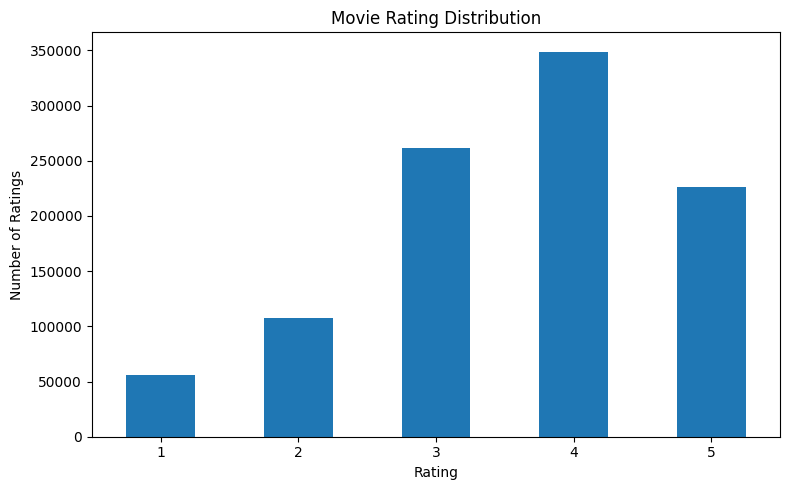

Chart saved successfully!


In [69]:
plt.figure(figsize=(8, 5))

ratings["rating"].value_counts().sort_index().plot(kind="bar")

plt.title("Movie Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("images/rating_distribution.png", dpi=300)
plt.show()

print("Chart saved successfully!")

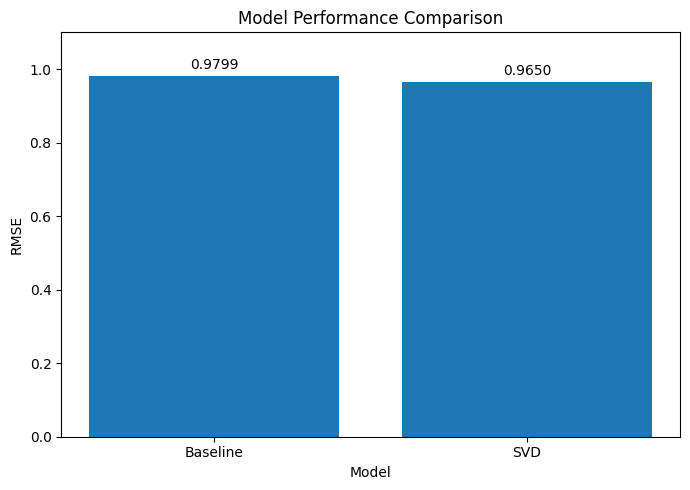

Model comparison chart saved successfully!


In [70]:
plt.figure(figsize=(7, 5))

plt.bar(
    ["Baseline", "SVD"],
    [0.9799, 0.9650]
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.ylim(0, 1.1)

for i, value in enumerate([0.9799, 0.9650]):
    plt.text(i, value + 0.02, f"{value:.4f}", ha="center")

plt.tight_layout()
plt.savefig("images/model_comparison.png", dpi=300)
plt.show()

print("Model comparison chart saved successfully!")

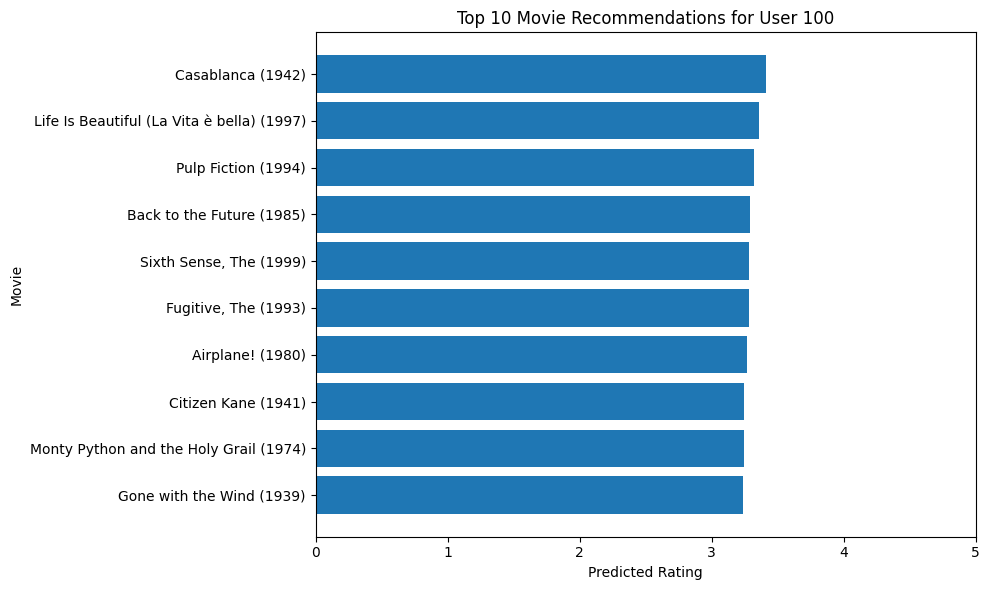

Recommendation chart saved successfully!


In [71]:
recommendations = svd_recommend(100, 10)

plt.figure(figsize=(10, 6))

plt.barh(
    recommendations["title"][::-1],
    recommendations["predicted_rating"][::-1]
)

plt.xlabel("Predicted Rating")
plt.ylabel("Movie")
plt.title("Top 10 Movie Recommendations for User 100")
plt.xlim(0, 5)

plt.tight_layout()
plt.savefig("images/recommendation_chart.png", dpi=300)
plt.show()

print("Recommendation chart saved successfully!")

In [72]:
import os

for root, dirs, files in os.walk("."):
    # Ignore unnecessary system folders
    if ".config" in root or "sample_data" in root:
        continue

    level = root.count(os.sep)
    indent = "    " * level

    if root != ".":
        print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        if file in [
            "requirements.txt",
            ".gitignore",
            "README.md",
            "model_results.csv",
            "top_k_results.csv",
            "user_100_recommendations.csv",
            "rating_distribution.png",
            "model_comparison.png",
            "recommendation_chart.png"
        ]:
            print(f"{indent}    {file}")

    .gitignore
    user_100_recommendations.csv
    requirements.txt
    top_k_results.csv
    model_results.csv
    data/
        README.md
    results/
        user_100_recommendations.csv
        top_k_results.csv
        model_results.csv
    ml-1m/
    images/
        model_comparison.png
        rating_distribution.png
        recommendation_chart.png


In [73]:
import os
import shutil

# Remove downloaded MovieLens dataset
if os.path.exists("ml-1m"):
    shutil.rmtree("ml-1m")

# Remove duplicate result files from root directory
for file in [
    "model_results.csv",
    "top_k_results.csv",
    "user_100_recommendations.csv"
]:
    if os.path.exists(file):
        os.remove(file)

print("Project workspace cleaned successfully!")

Project workspace cleaned successfully!


In [76]:
readme = """# Movie Recommendation System

A machine learning-based movie recommendation system built using the MovieLens 1M dataset.

## Project Overview

This project implements multiple recommendation techniques:

- Content-Based Filtering
- Collaborative Filtering
- Matrix Factorization using SVD
- Hybrid Recommendation
- Top-K Recommendation Evaluation

## Dataset

MovieLens 1M

- 3,883 movies
- 6,040 users
- 1,000,209 ratings

Dataset source:
https://grouplens.org/datasets/movielens/1m/

The original dataset is not included in this repository.

## Recommendation Methods

### 1. Content-Based Filtering

Uses movie genres to find similar movies.

Techniques:
- TF-IDF
- Cosine Similarity

### 2. Collaborative Filtering

Uses user-movie ratings to identify movies with similar rating patterns.

Techniques:
- User-Movie Rating Matrix
- Movie-Movie Cosine Similarity

### 3. Matrix Factorization

Uses Truncated SVD to discover latent relationships between users and movies.

Configuration:
- 50 latent factors

### 4. Hybrid Recommendation

Combines content-based and collaborative recommendations.

## Model Evaluation

### Rating Prediction

| Model | RMSE |
|---|---:|
| Baseline | 0.9799 |
| SVD | 0.9650 |

Lower RMSE indicates lower prediction error on the test split.

### Top-K Recommendation

| Metric | Score |
|---|---:|
| Precision@10 | 0.1801 |
| Recall@10 | 0.1067 |

Movies rated 4 or 5 in the test set were considered relevant.

## Visualizations

### Rating Distribution

![Rating Distribution](images/rating_distribution.png)

### Model Comparison

![Model Comparison](images/model_comparison.png)

### Example Recommendations

![Recommendations](images/recommendation_chart.png)

## Technologies Used

- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Google Colab

## Project Structure

movie-recommendation-system/

    notebooks/
        Movie_Recommendation_System_MovieLens_1M.ipynb

    data/
        README.md

    results/
        model_results.csv
        top_k_results.csv
        user_100_recommendations.csv

    images/
        rating_distribution.png
        model_comparison.png
        recommendation_chart.png

    README.md
    requirements.txt
    .gitignore

## How to Run

1. Clone the repository.
2. Install the required packages:

pip install -r requirements.txt

3. Download the MovieLens 1M dataset.
4. Open the notebook in Google Colab or Jupyter Notebook.
5. Run the cells sequentially.

## Example

For User 100, the SVD model generated recommendations including:

- Casablanca
- Life Is Beautiful
- Pulp Fiction
- Back to the Future
- The Sixth Sense

The predicted ratings are generated by the trained SVD model.

## Future Improvements

- Improve hybrid recommendation scoring
- Experiment with different SVD configurations
- Add cold-start handling
- Build a Streamlit web application
- Compare Python implementation with RapidMiner
- Deploy the recommendation system

## Author

AAHIL
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme)

print("README.md created successfully!")

README.md created successfully!
